# Prédiction SiteEnergyUseWN(kBtu)

In [23]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
ls -lh ./data

total 1,4M
-rw-r--r-- 1 mijka mijka 1,2M 24 mai   10:58 2016_Building_Energy_Benchmarking.csv
-rw-r--r-- 1 mijka mijka 136K 12 févr. 09:54 clean_seattle_buildings.csv


In [4]:
path = './data/'
filename = 'clean_seattle_buildings.csv'
csv_path = path + filename
df = pd.read_csv(csv_path, on_bad_lines='skip', low_memory=False)

In [5]:
df.head()

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUseWN(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,No UseType,No UseType,60.0,7456910.0,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Hotel,Parking,Restaurant,61.0,8664479.0,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,No UseType,No UseType,43.0,73937112.0,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,No UseType,No UseType,56.0,6946800.5,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Hotel,Parking,Swimming Pool,75.0,14656503.0,505.01


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1023 non-null   object 
 1   PrimaryPropertyType           1023 non-null   object 
 2   ZipCode                       1023 non-null   float64
 3   Neighborhood                  1023 non-null   object 
 4   YearBuilt                     1023 non-null   int64  
 5   NumberofBuildings             1023 non-null   float64
 6   NumberofFloors                1023 non-null   int64  
 7   PropertyGFATotal              1023 non-null   int64  
 8   PropertyGFAParking            1023 non-null   int64  
 9   PropertyGFABuilding(s)        1023 non-null   int64  
 10  LargestPropertyUseType        1023 non-null   object 
 11  SecondLargestPropertyUseType  1023 non-null   object 
 12  ThirdLargestPropertyUseType   1023 non-null   object 
 13  ENE

In [6]:
df.dtypes

BuildingType                     object
PrimaryPropertyType              object
ZipCode                         float64
Neighborhood                     object
YearBuilt                         int64
NumberofBuildings               float64
NumberofFloors                    int64
PropertyGFATotal                  int64
PropertyGFAParking                int64
PropertyGFABuilding(s)            int64
LargestPropertyUseType           object
SecondLargestPropertyUseType     object
ThirdLargestPropertyUseType      object
ENERGYSTARScore                 float64
SiteEnergyUseWN(kBtu)           float64
TotalGHGEmissions               float64
dtype: object

In [8]:
df.shape

(1023, 16)

In [21]:
df.isna().sum()

BuildingType                    0
PrimaryPropertyType             0
ZipCode                         0
Neighborhood                    0
YearBuilt                       0
NumberofBuildings               0
NumberofFloors                  0
PropertyGFATotal                0
PropertyGFAParking              0
PropertyGFABuilding(s)          0
LargestPropertyUseType          0
SecondLargestPropertyUseType    0
ThirdLargestPropertyUseType     0
SiteEnergyUseWN(kBtu)           0
TotalGHGEmissions               0
dtype: int64

In [10]:
#save separately energy star score
energy_star_score = df['ENERGYSTARScore']
df.drop('ENERGYSTARScore', axis=1, inplace=True)
df.shape

(1023, 15)

In [11]:
#df.isna().sum().sum()

# Prep Vectors & Matrices

In [12]:
y = df.copy()[{'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions'}]
X = df.copy().drop(['SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions'], axis=1)

label = 'SiteEnergyUseWN(kBtu)' # change label if needed

## Normalisation & One Hot Encoder

### isoler var num et var cat

In [15]:
categorical_columns = X.select_dtypes(['category','object']).columns
numerical_columns = X.select_dtypes(['int32','float64']).columns

In [16]:
categorical_columns

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType'],
      dtype='object')

In [17]:
numerical_columns

Index(['ZipCode', 'NumberofBuildings'], dtype='object')

In [18]:
df.describe()

,ZipCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUseWN(kBtu),TotalGHGEmissions
count,1023.000000,1023.000000,1023.000000,1023.00000,1.023000e+03,1023.000000,1.023000e+03,1.023000e+03,1023.000000
mean,98116.467253,1963.283480,1.044966,4.85826,1.245587e+05,15167.322581,1.093914e+05,8.629258e+06,184.392688
std,17.512608,31.601602,0.482504,7.94923,2.033426e+05,46280.616303,1.769342e+05,2.601223e+07,848.363277
min,98020.000000,1900.000000,1.000000,0.00000,1.630000e+04,0.000000,1.620000e+04,7.996790e+04,-0.800000
25%,98104.000000,1938.000000,1.000000,1.00000,3.254550e+04,0.000000,3.132150e+04,1.396912e+06,20.560000
50%,98109.000000,1967.000000,1.000000,3.00000,5.373000e+04,0.000000,5.105000e+04,2.789344e+06,49.250000
75%,98122.000000,1989.000000,1.000000,5.00000,1.229710e+05,0.000000,1.060205e+05,7.424380e+06,130.655000
max,98199.000000,2015.000000,9.000000,99.00000,1.952220e+06,512608.000000,1.765970e+06,4.716139e+08,16870.980000


In [19]:
df[categorical_columns].describe()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
count,1023,1023,1023,1023,1023,1023
unique,4,14,13,19,31,29
top,NonResidential,Small- and Mid-Sized Office,DOWNTOWN,Office,No UseType,No UseType
freq,929,235,236,396,555,880


In [20]:
df[categorical_columns].dtypes

BuildingType                    object
PrimaryPropertyType             object
Neighborhood                    object
LargestPropertyUseType          object
SecondLargestPropertyUseType    object
ThirdLargestPropertyUseType     object
dtype: object

### Normalisation num cats

In [ ]:
ss = StandardScaler()

In [22]:
### normaliser num
X[numerical_columns] = ss.fit_transform(X[numerical_columns])

### Encoding

#### Check categorical features

In [14]:
X.shape

(1023, 13)

In [13]:
X.select_dtypes(['category','object']).nunique()

BuildingType                     4
PrimaryPropertyType             14
Neighborhood                    13
LargestPropertyUseType          19
SecondLargestPropertyUseType    31
ThirdLargestPropertyUseType     29
dtype: int64

In [38]:
X.select_dtypes(['category','object']).head()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
1,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Restaurant
2,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
3,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
4,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Swimming Pool


In [24]:
df['LargestPropertyUseType'].unique()

array(['Hotel', 'Courthouse', 'K-12 School', 'Office', 'Medical Office',
       'Retail Store', 'Hospital (General Medical & Surgical)',
       'Financial Office', 'Non-Refrigerated Warehouse',
       'Worship Facility', 'Data Center', 'Parking',
       'Supermarket/Grocery Store', 'Distribution Center',
       'Wholesale Club/Supercenter', 'Refrigerated Warehouse', 'Other',
       'No UseType', 'Bank Branch'], dtype=object)

**Encoding strategy :**

=> BuildingType => OHE

=> other features => OrdinalEncoder

In [34]:
ohe_features = ['BuildingType']
ord_features = X.drop(['BuildingType'], axis=1).select_dtypes(['category','object']).columns.to_list()

In [35]:
ohe = OneHotEncoder(sparse=False)
ord = OrdinalEncoder()

#### OHE

#### OrdinalEncoder

In [25]:
# => réencoder manuellement en classes générales

In [26]:
ohe.fit_transform(X[categorical_columns])

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [27]:
X[categorical_columns].head()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
1,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Restaurant
2,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
3,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
4,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Swimming Pool


In [28]:
X[categorical_columns].head()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
1,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Restaurant
2,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
3,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType
4,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Swimming Pool


In [29]:
X = pd.merge(X[categorical_columns], 
          pd.DataFrame(columns = ohe.get_feature_names().tolist(),
              data = ohe.fit_transform(X[categorical_columns])),
        left_index = True, right_index = True)

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Columns: 116 entries, BuildingType to x5_Swimming Pool
dtypes: float64(110), object(6)
memory usage: 927.2+ KB


In [87]:
X.shape

(1023, 110)

In [31]:
X.head()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,x0_Campus,x0_NonResidential,x0_Nonresidential COS,x0_SPS-District K-12,x1_Distribution Center,x1_Hospital,x1_Hotel,x1_K-12 School,x1_Large Office,x1_Medical Office,x1_Mixed Use Property,x1_Other,x1_Refrigerated Warehouse,x1_Retail Store,x1_Small- and Mid-Sized Office,x1_Supermarket / Grocery Store,x1_Warehouse,x1_Worship Facility,x2_BALLARD,x2_CENTRAL,x2_DELRIDGE,x2_DOWNTOWN,x2_EAST,x2_GREATER DUWAMISH,x2_LAKE UNION,x2_MAGNOLIA / QUEEN ANNE,x2_NORTH,x2_NORTHEAST,x2_NORTHWEST,x2_SOUTHEAST,x2_SOUTHWEST,x3_Bank Branch,x3_Courthouse,x3_Data Center,x3_Distribution Center,x3_Financial Office,x3_Hospital (General Medical & Surgical),x3_Hotel,x3_K-12 School,x3_Medical Office,x3_No UseType,x3_Non-Refrigerated Warehouse,x3_Office,x3_Other,x3_Parking,x3_Refrigerated Warehouse,x3_Retail Store,x3_Supermarket/Grocery Store,x3_Wholesale Club/Supercenter,x3_Worship Facility,x4_Adult Education,x4_Bank Branch,x4_Bar/Nightclub,x4_College/University,x4_Convenience Store without Gas Station,x4_Data Center,x4_Distribution Center,x4_Financial Office,x4_Hotel,x4_K-12 School,x4_Laboratory,x4_Manufacturing/Industrial Plant,x4_Medical Office,x4_No UseType,x4_Non-Refrigerated Warehouse,x4_Office,x4_Other,x4_Other - Education,x4_Other - Entertainment/Public Assembly,x4_Other - Recreation,x4_Other - Restaurant/Bar,x4_Other - Services,x4_Parking,x4_Performing Arts,x4_Pre-school/Daycare,x4_Restaurant,x4_Retail Store,x4_Self-Storage Facility,x4_Supermarket/Grocery Store,x4_Swimming Pool,x4_Worship Facility,x5_Bank Branch,x5_Bar/Nightclub,x5_Convenience Store without Gas Station,x5_Data Center,x5_Distribution Center,x5_Financial Office,x5_Fitness Center/Health Club/Gym,x5_Food Service,x5_Laboratory,x5_Medical Office,x5_No UseType,x5_Non-Refrigerated Warehouse,x5_Office,x5_Other,x5_Other - Education,x5_Other - Entertainment/Public Assembly,x5_Other - Recreation,x5_Other - Restaurant/Bar,x5_Other - Services,x5_Other - Technology/Science,x5_Other/Specialty Hospital,x5_Parking,"x5_Personal Services (Health/Beauty, Dry Cleaning, etc)",x5_Pre-school/Daycare,x5_Refrigerated Warehouse,x5_Restaurant,x5_Retail Store,x5_Social/Meeting Hall,x5_Swimming Pool
0,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NonResidential,Hotel,DOWNTOWN,Hotel,Parking,Restaurant,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NonResidential,Hotel,DOWNTOWN,Hotel,No UseType,No UseType,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.

In [32]:
#import re
#regex = re.compile(r'x\d_')
#for column in X.columns:
#    if regex.search(column):
#        X[column] = X[column].astype('int32')

In [33]:
categorical_columns

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType'],
      dtype='object')

In [34]:
X.drop(columns=categorical_columns, inplace = True)
X.head()

,x0_Campus,x0_NonResidential,x0_Nonresidential COS,x0_SPS-District K-12,x1_Distribution Center,x1_Hospital,x1_Hotel,x1_K-12 School,x1_Large Office,x1_Medical Office,x1_Mixed Use Property,x1_Other,x1_Refrigerated Warehouse,x1_Retail Store,x1_Small- and Mid-Sized Office,x1_Supermarket / Grocery Store,x1_Warehouse,x1_Worship Facility,x2_BALLARD,x2_CENTRAL,x2_DELRIDGE,x2_DOWNTOWN,x2_EAST,x2_GREATER DUWAMISH,x2_LAKE UNION,x2_MAGNOLIA / QUEEN ANNE,x2_NORTH,x2_NORTHEAST,x2_NORTHWEST,x2_SOUTHEAST,x2_SOUTHWEST,x3_Bank Branch,x3_Courthouse,x3_Data Center,x3_Distribution Center,x3_Financial Office,x3_Hospital (General Medical & Surgical),x3_Hotel,x3_K-12 School,x3_Medical Office,x3_No UseType,x3_Non-Refrigerated Warehouse,x3_Office,x3_Other,x3_Parking,x3_Refrigerated Warehouse,x3_Retail Store,x3_Supermarket/Grocery Store,x3_Wholesale Club/Supercenter,x3_Worship Facility,x4_Adult Education,x4_Bank Branch,x4_Bar/Nightclub,x4_College/University,x4_Convenience Store without Gas Station,x4_Data Center,x4_Distribution Center,x4_Financial Office,x4_Hotel,x4_K-12 School,x4_Laboratory,x4_Manufacturing/Industrial Plant,x4_Medical Office,x4_No UseType,x4_Non-Refrigerated Warehouse,x4_Office,x4_Other,x4_Other - Education,x4_Other - Entertainment/Public Assembly,x4_Other - Recreation,x4_Other - Restaurant/Bar,x4_Other - Services,x4_Parking,x4_Performing Arts,x4_Pre-school/Daycare,x4_Restaurant,x4_Retail Store,x4_Self-Storage Facility,x4_Supermarket/Grocery Store,x4_Swimming Pool,x4_Worship Facility,x5_Bank Branch,x5_Bar/Nightclub,x5_Convenience Store without Gas Station,x5_Data Center,x5_Distribution Center,x5_Financial Office,x5_Fitness Center/Health Club/Gym,x5_Food Service,x5_Laboratory,x5_Medical Office,x5_No UseType,x5_Non-Refrigerated Warehouse,x5_Office,x5_Other,x5_Other - Education,x5_Other - Entertainment/Public Assembly,x5_Other - Recreation,x5_Other - Restaurant/Bar,x5_Other - Services,x5_Other - Technology/Science,x5_Other/Specialty Hospital,x5_Parking,"x5_Personal Services (Health/Beauty, Dry Cleaning, etc)",x5_Pre-school/Daycare,x5_Refrigerated Warehouse,x5_Restaurant,x5_Retail Store,x5_Social/Meeting Hall,x5_Swimming Pool
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [35]:
X.shape

(1023, 110)

In [36]:
y.shape

(1023, 2)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
            train_test_split(X, 
                             y[label],  
                             test_size = 0.2, 
                             random_state = 42
                            )

In [38]:
X_train.shape

(818, 110)

In [39]:
X_test.shape

(205, 110)

In [40]:
y_train.shape

(818,)

In [41]:
y_test.shape

(205,)

# Modélisation

In [56]:
results = pd.DataFrame({})

In [58]:
from datetime import datetime

now = datetime.now()

current_time = now.strftime("%H:%M:%S.%f")
print("Current Time =", current_time)

Current Time = 09:39:24.557784


In [83]:
current_time2 = datetime.now()
#.strftime("%H:%M:%S.%f")

In [84]:
current_time3 = datetime.now()

In [86]:
current_time3 - current_time2

datetime.timedelta(seconds=6, microseconds=267891)

## Linear Regressor

In [42]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

In [43]:
model = LinearRegression()

cv_results = cross_validate(model, X_train, y_train, cv=10)

In [44]:
base_model_score = cv_results['test_score'].mean()

In [45]:
base_model_score

-1.1100680490907777e+26

In [ ]:
gscv = GridSearchCV(estimator=reg, scoring="neg_mean_squared_error", cv=SPLITS, param_grid=param_grid_reg, verbose=5)
gscv.fit(X,Y)

print("Score", gscv.best_score_)
print("Params", gscv.best_params_)

## ElasticNet

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [47]:
from sklearn.linear_model import ElasticNet

#rappel de la fonction de coût du elasticnet
#1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

parameters = {'tol' : [0.1,0.01,0.001,0.0001],
              "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  #alpha, coef qui multiplie le terme de pénalité)
              "l1_ratio": np.arange(0.0, 1.0, 0.1)}#L1 ratio , =1 équivaut à un Lasso, 0 à un Ridge


elastic_grid = GridSearchCV(estimator = ElasticNet(), 
                      param_grid = parameters,
                      scoring = 'neg_mean_squared_error',
                      cv=5,
                      verbose=0
                     )

elastic_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                         'l1_ratio': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'tol': [0.1, 0.01, 0.001, 0.0001]},
             scoring='neg_mean_squared_error')

In [48]:
elastic_grid.best_params_

{'alpha': 0.01, 'l1_ratio': 0.0, 'tol': 0.1}

In [49]:
elastic_grid.best_score_

-596538845422061.0

## Random Forest

In [50]:
from sklearn.ensemble import RandomForestRegressor

parameters = {
    'n_estimators' : [10,50,100,300,500], #nombre d'arbres de décision
    'min_samples_leaf' : [1,3,5,10], #nombre de feuilles minimales dans un noeud
    'max_features': ['auto', 'sqrt'] #nombre de features observées pour chaque arbre
}

In [51]:
rfr_search = GridSearchCV(RandomForestRegressor(),
                               param_grid = parameters,
                               #scoring='mean_squared_error',
                              verbose=2,
                               cv=5)

rfr_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.1s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.2s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.2s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.2s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.2s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=50; total time=   0.2s
[CV] END max_features=auto, min_samples_leaf=1, n_estimators=100; total time=   0.5s
[CV] END max_

[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   0.8s
[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   0.9s
[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   0.9s
[CV] END max_features=auto, min_samples_leaf=10, n_estimators=500; total time=   1.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=10; total time=   0.0s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_features=sqrt, min_samples_leaf=1, n_estimators=50; tot

[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=300; total time=   0.3s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=300; total time=   0.3s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   0.5s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   0.5s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   0.5s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   0.5s
[CV] END max_features=sqrt, min_samples_leaf=10, n_estimators=500; total time=   0.5s


GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 3, 5, 10],
                         'n_estimators': [10, 50, 100, 300, 500]},
             verbose=2)

In [52]:
rfr_search.best_params_

{'max_features': 'auto', 'min_samples_leaf': 1, 'n_estimators': 10}

In [75]:
results = pd.DataFrame({})

In [77]:
import math
results = results.append(pd.DataFrame({
    'Modèle' : ['Random Forest Regressor'],
    'Score_RMSE' : [math.sqrt(mean_squared_error(rfr_search.predict(X_test), y_test))]}),
              ignore_index=True),
    #''

coefficients = abs(rfr_search.best_estimator_.feature_importances_)
liste_coefs_rer = pd.concat((pd.DataFrame(X.columns, columns = ['Variable']), 
                      pd.DataFrame(coefficients, columns = ['Coefficient'])), axis = 1).sort_values(by='Coefficient', ascending = False)

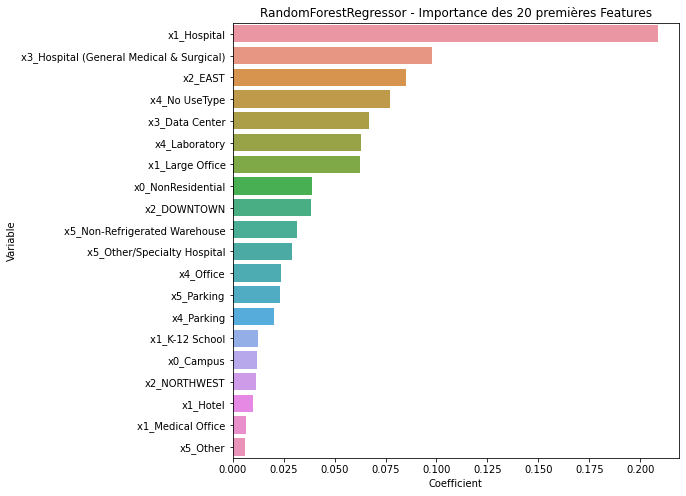

In [55]:
plt.figure(figsize=(8,8))
plt.title('RandomForestRegressor - Importance des 20 premières Features')
sns.barplot(y = liste_coefs_rer['Variable'].head(20),
            x = liste_coefs_rer['Coefficient'].head(20))
plt.show()

In [78]:
results

(                    Modèle    Score_RMSE
 0  Random Forest Regressor  1.879058e+07,)

In [56]:
# 3 preds différentes (regression...mini une linéaire et une non-linéaire ex: linear regressor, random forest)
# optimisation hyper paramètres

## comparer avec même score (RMSE, R² (surtout pour linéaires))
## logger + comparer temps de test/entraînement
## ressortir tableau comparatif
## choisir meilleur

## une fois modele choisi, ajouter energystarscore
## evaluer si cela améliore ou non la modélisation
## utiliser librairie pour évaluer => librairie SHAP


In [ ]:
## utiliser 'neg_root_mean_squared_error' en scoring

In [57]:
## possibilité de lister différents scorings à calculer en une fois => doc

In [58]:
## essayer assembliste / random forest / svr / linearregression 
## check doc scikitlab regresseurs
## /!\ ne pas oublier normalisation

In [59]:
## /!\ 2 targets => virer les 2 => 2 colonnes de moins pour l'ordinal encoding puis ajouter une target à la fois par training

In [60]:
# analyse
# nettoyage (outliers + valeurs vides)
# (penser à encoder null en une autre valeur si besoin, par ex pour l'encoding, puis signifier à l'inputer que telle valeur est nulle)
# encoding
# encode > cat > -5 : OHE
#                +5 : ordinal
#         > cat > 

## GradientBoostingRegressor

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html